%%% Exemple sintonització ZN
% Implementar PID a un sistema de 3r ordre
% J.A.Mayugo, UdG, 2023

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

1. SISTEMA

In [8]:
# Gm(s) = 6 / (48 s^3 + 44 s^2 + 12 s + 1)
numG = [6]
denG = [48, 44, 12, 1]

G_m = signal.lti(numG, denG)

t_f = 60
t_inc = 0.1
t = np.arange(0, t_f + t_inc, t_inc)
u = np.ones_like(t)

2. BODE i ROOT LOCUS

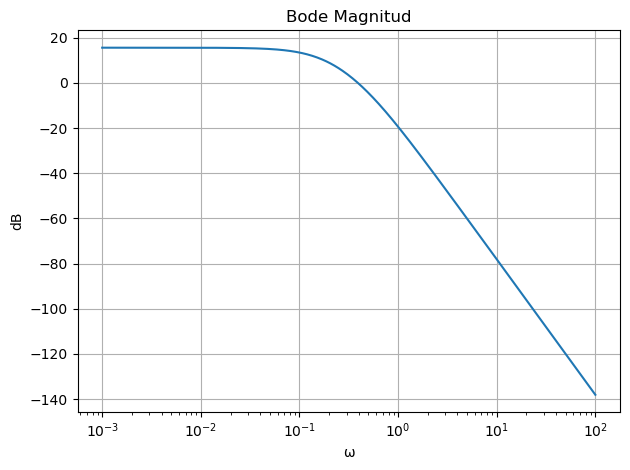

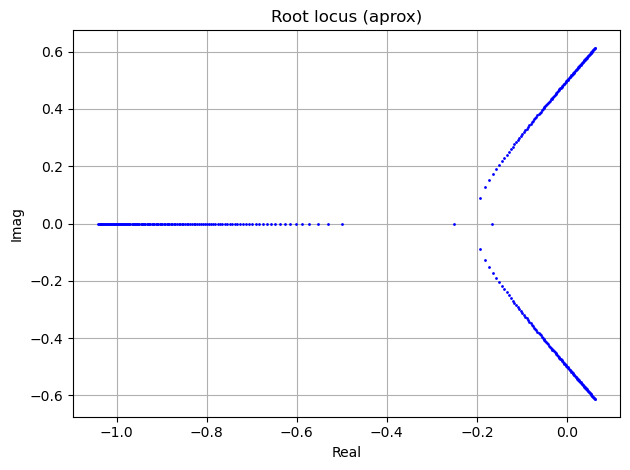

In [9]:
w = np.logspace(-3, 2, 600)
w, H = signal.freqresp((numG, denG), w)

plt.figure()
plt.semilogx(w, 20*np.log10(np.abs(H)))
plt.grid()
plt.title("Bode Magnitud")
plt.xlabel("ω")
plt.ylabel("dB")
plt.tight_layout()

K_values = np.linspace(0, 3, 120)
poles_list = []

for Kk in K_values:
    numK = np.polymul([Kk], numG)
    den_cl = np.polyadd(denG, numK)
    poles_list.append(np.roots(den_cl))

plt.figure()
for p in poles_list:
    plt.plot(np.real(p), np.imag(p), 'b.', markersize=2)

plt.grid()
plt.title("Root locus (aprox)")
plt.xlabel("Real")
plt.ylabel("Imag")
plt.tight_layout()

3. RESPONSE OPEN LOOP


PID ZN (OPEN LOOP DESIGN)
T : 14.825044687798727
K : 5.998781543551798
L : 2.867843383520234


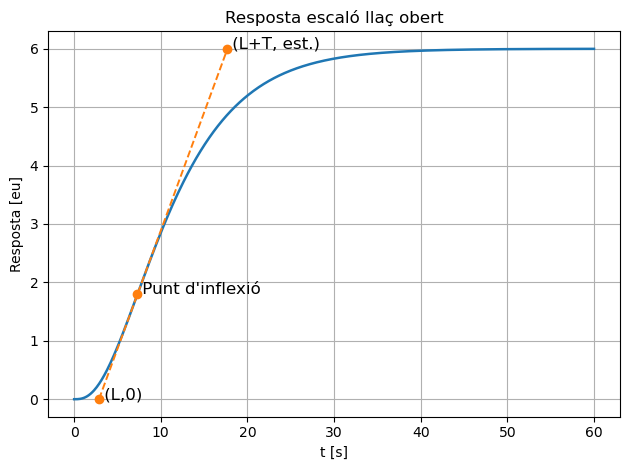

In [10]:
t_ol, y_ol, _ = signal.lsim(G_m, U=u, T=t)

dY = np.diff(y_ol) / 0.1
I = np.argmax(dY)

DeltaY = dY[I]

out = [0, y_ol[I], np.max(y_ol)]

t_pts = np.zeros(3)
t_pts[0] = t[I] - out[1] / DeltaY
t_pts[1] = t[I]
t_pts[2] = t[I] + (out[2] - out[1]) / DeltaY

L = t_pts[0]
T = t_pts[2] - t_pts[0]
Kstatic = np.max(y_ol)

print('\nPID ZN (OPEN LOOP DESIGN)')
print(f'T : {T}')
print(f'K : {Kstatic}')
print(f'L : {L}')

plt.figure()
plt.plot(t_ol, y_ol, linewidth=1.8)
plt.plot(t_pts, out, "--o", linewidth=1.4)

plt.grid()
plt.title("Resposta escaló llaç obert")
plt.xlabel("t [s]")
plt.ylabel("Resposta [eu]")

plt.text(t_pts[0], out[0], " (L,0)", fontsize=12)
plt.text(t_pts[1], out[1], " Punt d'inflexió", fontsize=12)
plt.text(t_pts[2], out[2], " (L+T, est.)", fontsize=12)

plt.tight_layout()

4. PID ZN (OPEN LOOP DESIGN)

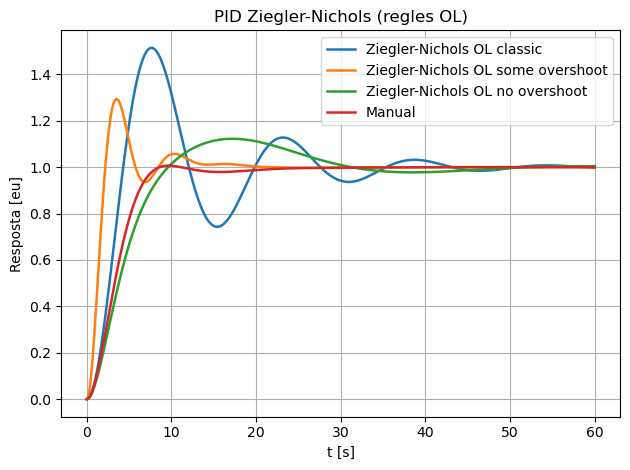

In [11]:
Label_ = [
    'Ziegler-Nichols OL classic',
    'Ziegler-Nichols OL some overshoot',
    'Ziegler-Nichols OL no overshoot',
    'Manual']

Kp_ = [
    1.2 * T / L / Kstatic,
    (1.2 * T / L * 0.6 / 0.33) / Kstatic,
    (1.2 * T / L / 3) / Kstatic,
    (1.2 * T / L / 2) / Kstatic]
Ti_ = [ 2 * L, 2 * L, 2 * L, 2 * L * 2]
Td_ = [ 0.5 * L, 0.5 * L * 8/3, 0.5 * L * 8/3, 0.5 * L * 2]

responses = []

for Kp, Ti, Td in zip(Kp_, Ti_, Td_):

    numC = [Kp*Td, Kp, Kp/Ti]
    denC = [1, 0]

    num_ol = np.polymul(numC, numG)
    den_ol = np.polymul(denC, denG)

    num_cl = num_ol
    den_cl = np.polyadd(den_ol, num_ol)

    sys_cl = signal.lti(num_cl, den_cl)

    t_out, y, _ = signal.lsim(sys_cl, U=u, T=t)

    responses.append(y)

plt.figure()

for y, label in zip(responses, Label_):
    plt.plot(t, y, linewidth=1.8, label = label )

plt.title("PID Ziegler-Nichols (regles OL)")
plt.xlabel("t [s]")
plt.ylabel("Resposta [eu]")
plt.grid()
plt.legend()
plt.tight_layout()

5. PID ZN (CL RULES)

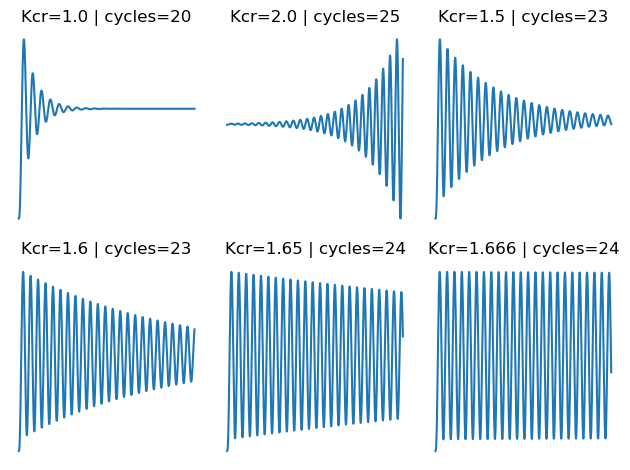

In [12]:
t_long = np.arange(0, 300, 0.1)
u_long = np.ones_like(t_long)

Kcr_values = [1.0, 2.0, 1.5, 1.6, 1.65, 1.666]
num_cycles = []

plt.figure()

for i, Kcr in enumerate(Kcr_values):

    num_cl = np.polymul([Kcr], numG)
    den_cl = np.polyadd(denG, np.polymul([Kcr], numG))

    sys = signal.lti(num_cl, den_cl)
    t_out, y, _ = signal.lsim(sys, U=u_long, T=t_long)

    peaks, _ = signal.find_peaks(y)
    cycles = len(peaks) - 0.  # estimació de cicles
    if cycles < 0:
        cycles = 0

    num_cycles.append(cycles)

    plt.subplot(2, 3, i+1)
    plt.plot(t_out, y)
    plt.title(f"Kcr={Kcr} | cycles={int(cycles)}")
    plt.axis("off")

plt.tight_layout()

Pcr = 300/num_cycles[-1]


PID ZN (CLOSE LOOP RULES)
Pcr: 12.5


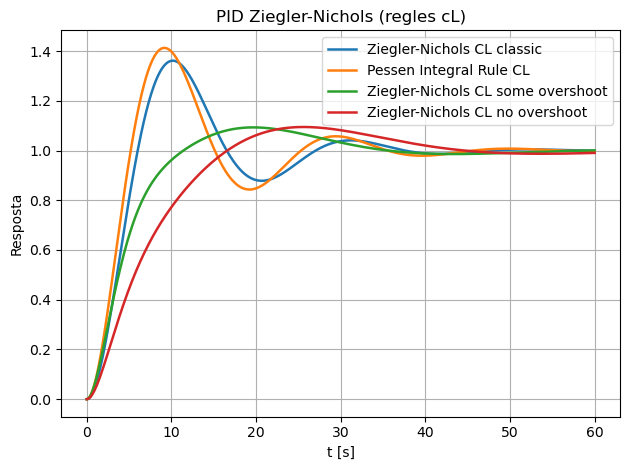

: 

In [ ]:


print('\nPID ZN (CLOSE LOOP RULES)')
print('Pcr:', Pcr)

Label2_ = ['Ziegler-Nichols CL classic',
               'Pessen Integral Rule CL',
               'Ziegler-Nichols CL some overshoot',
               'Ziegler-Nichols CL no overshoot']
Kp2_ = [0.6, 0.7, 0.33, 0.2]
Ti2_ = [Pcr/2, Pcr/2.5, Pcr/2, Pcr/2]
Td2_ = [Pcr/8, 0.15*Pcr, Pcr/3, Pcr/3]

responses2 = []

for Kp, Ti, Td in zip(Kp2_, Ti2_, Td2_):

    numC = [Kp*Td, Kp, Kp/Ti]
    denC = [1, 0]

    num_ol = np.polymul(numC, numG)
    den_ol = np.polymul(denC, denG)

    num_cl = num_ol
    den_cl = np.polyadd(den_ol, num_ol)

    sys_cl = signal.lti(num_cl, den_cl)

    t_out, y, _ = signal.lsim(sys_cl, U=u, T=t)

    responses2.append(y)

plt.figure()

for y, label in zip(responses2, Label2_):
    plt.plot(t, y, linewidth=1.8, label = label)

plt.title("PID Ziegler-Nichols (regles cL)")
plt.xlabel("t [s]")
plt.ylabel("Resposta")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()